<a href="https://colab.research.google.com/github/tustus1022-ui/esaa/blob/main/hw_transcription11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

파이썬 머신러닝 완벽가이드 ch4. 3~6 (pg. 210-244) -> pdf 228-262

### 분류
**앙상블 학습**
#### 앙상블 학습 개요

앙상블 학습(Ensemble Learning)을 통한 분류 : 여러 개의 분류기 (Classifier)를 생성하고 그 예측을 결합함으로써 보다 정확한 최종
예측을 도출하는 기법
앙상블 학습의 유형은 전통적으로 보팅(Voting), 배깅(Bagging), 부스팅(Boosting)의 세 가지로 나눌 수 있으며, 이 외에도 스태깅을 포함한 다양한 앙상블 방법이 있다.
- 보팅과 배깅 : 여러 개의 분류기가 투표를 통해 최종 예측 결과를 결정하는 방식
- 보팅과 배깅의 다른 점 : 보팅의 경우 일반적으로 서로 다른 알고리즘을 가진 분류기를 결합하는 것이고, 배깅의 경우 각각의 분류기가 모두 같
은 유형의 알고리즘 기반이지만, 데이터 샘플링을 서로 다르게 가져가면서 학습을 수행해 보팅을 수행
하는 것
- 대표적인 배깅 방식 : 바로 랜덤 포레스트 알고리즘

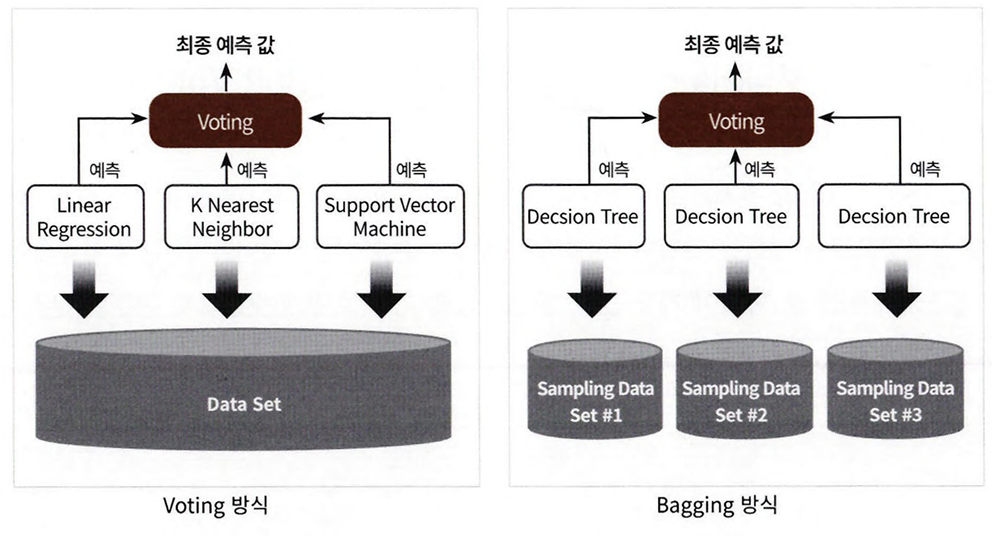

- Voting 방식

선형 회귀, K 최근접 이웃, 서포트 벡터 머신이라는 3개의 ML 알고리즘이 같은 데이터 세트에 대해 학습하고 예측한 결과를 가지고 보팅을 통해 최종 예측 결과를 선정하는 방식
- Bagging 방식

개별 분류기에 할당된 학습 데이터는 원본 학습 데이터를 샘플링해 추출하는데, 이렇게 개별 Classifier에게 데이터를 샘플링해서 추출하는 방식을 부트스트래핑(Bootstrapping) 분할 방식이라고 부른다. 개별 분류기가 부트스트래핑 방식으로 샘플링된 데이터 세트에 대해서 학습을 통해 개별적인 예측을 수행한 결과를 보팅을 통해서 최종 예측 결과를 선정하는 방식이 바로 배깅 앙상블 방식

교차 검증이 데이터 세트 간에 중첩을 허용하지 않는 것과 다르게 배깅 방식은 중첩을 허용한다. 따라서 10000개의 데이터를 10개의 분류기가 배깅 방식으로 나누더라도 각 1000개의 데이터 내에는 중복된 데이터가 있다.

부스팅은 여러 개의 분류기가 순차적으로 학습을 수행하되, 앞에서 학습한 분류기가 예측이 틀린 데이터에 대해서는 올바르게 예측할 수 있도록 다음 분류기에게는 가중치(weight)를 부여하면서 학습과 예측을 진행

#### 보팅 유형 - 하드 보팅(Hard Voting)과 소프트 보팅(Soft Voting)

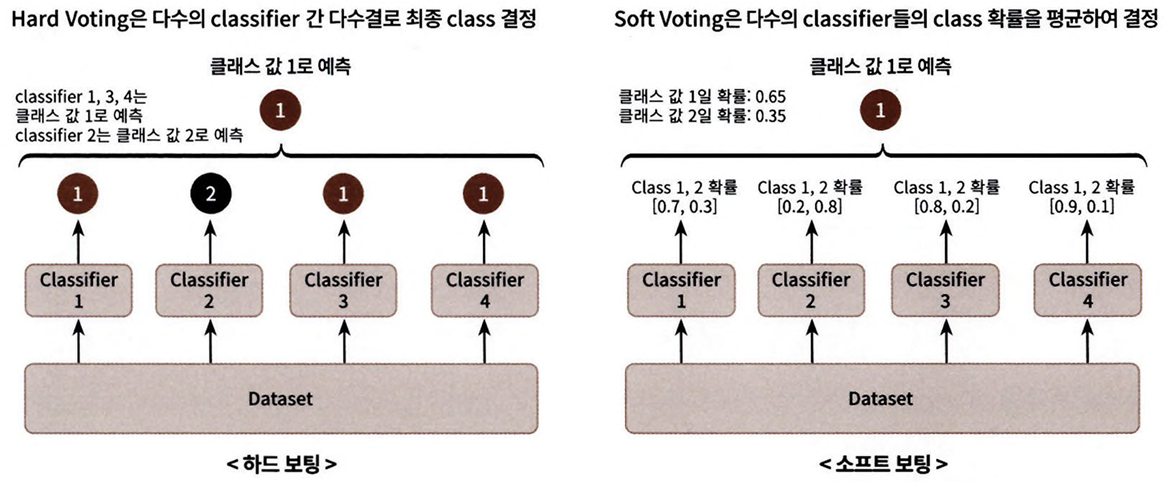

- 하드 보팅

다수결 원칙과 비슷. 예측한 결괏값들 중 다수의 분류기가 결정한 예측값을
최종 보팅 결괏값으로 선정

- 소프트 보팅 <- 일반적으로 적용됨

분류기들의 레이블 값 결정 확률을 모두 더하고 이를 평균해서 이들 중 확률이 가장 높은 레이블 값을 최종 보팅 결괏값으로 선정

#### 보팅 분류기 (Voting Classifier)

- 사이킷런은 보팅 방식의 앙상블을 구현한 VotingClassifier 클래스를 제공함

보팅 방식의 앙상블을 이용해 위스콘신 유방암 데이터 세트를 예측 분석해 보겠다. 위스콘신 유방암 데이터 세트는 유방암의 악성종양, 양성종양 여부를 결정하는 이진 분류 데이터 세트이며 종양의 크기, 모양 등의 형태와 관련한 많은 피처를 가지고 있다. 사이킷런은 load_breast_cancer() 함수를 통해 자체에서 위스콘신 유방암 데이터 세트를 생성할 수 있다.

- 로지스틱 회귀와 KNN을 기반으로 보팅 분류기 만들기

In [ ]:
# 필요한 모듈과 데이터를 로딩한 후 위스콘신 데이터 세트 살펴보기
import pandas as pd

from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

cancer = load_breast_cancer()

data_df = pd.DataFrame(cancer.data, columns = cancer.feature_names)
data_df.head(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


- 로지스틱 회귀와 KNN을 기반으로 소프트 보팅 방식으로 새롭게 보팅 분류기 만들기

In [ ]:
# 개별 모델은 로지스틱 회귀와 KNN임.
Ir_clf = LogisticRegression(solver='liblinear')
knn_clf = KNeighborsClassifier(n_neighbors=8)

# 개별 모델을 소프트 보팅 기반의 앙상블 모델로 구현한 분류기
vo_clf = VotingClassifier(estimators=[('LR', Ir_clf), ('KNN', knn_clf)], voting='soft')
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, test_size=0.2, random_state=156)

# VotingClassifier 학습/예측/평가.
vo_clf.fit(X_train, y_train)
pred = vo_clf.predict(X_test)
print('Voting 분류기 정확도: {0:.4f}'.format(accuracy_score(y_test, pred)))

# 개별 모델의 학습/예측/평가.
classifiers = [Ir_clf, knn_clf]
for classifier in classifiers:
  classifier.fit(X_train, y_train)
  pred = classifier.predict(X_test)
  class_name = classifier.__class__.__name__
  print('{0} 정확도: {1:.4f}'.format(class_name, accuracy_score(y_test, pred)))

Voting 분류기 정확도: 0.9561
LogisticRegression 정확도: 0.9474
KNeighborsClassifier 정확도: 0.9386


ML 모델의 성능은 다양한 테스트 데이터에 의해 검증되므로 어떻게 높은 유연성을 가지고 현실에 대처할 수 있는가가 중요한 ML 모델의 평가요소가 된다. 이런 관점에서 편향-분산 트레이드오프는 ML 모델이 극복해야 할 중요 과제이다.

보팅과 스태킹 등은 서로 다른 알고리즘을 기반으로 하고 있지만, 배깅과 부스팅은 대부분 결정 트리 알고리즘을 기반으로 한다. 결정 트리 알고리즘은 쉽고 직관적인 분류 기준을 가지고 있지만 정확한 예측을 위해 학습 데이터의 예외 상황에 집착한 나머지 오히려 과적합이 발생해 실제 테스트 데이터에서 예측 성능이 떨어지는 현상이 발생하기 쉽다. 하지만 앙상블 학습에서는 이 같은 결정 트리 알고리즘의 단점을 수십~수천 개의 매우 많은 분류기를 결합해 다양한 상황을 학습하게 함으로써 극복하고 있다. 결정 트리 알고리즘의 장점은 그대로 취하고 단점은 보완하면서 편향-분산 트레이드오프의 효과를 극대화할 수 있다는 것이다.

**랜덤 포레스트**

#### 랜덤 포레스트의 개요 및 실습

배깅(bagging): 앞에서 소개한 보팅과는 다르게, 같은 알고리즘으로 여러 개의 분류기를 만들어서 보팅으로 최종 결정하는 알고리즘

배깅의 대표적인 알고리즘: 랜덤 포레스트

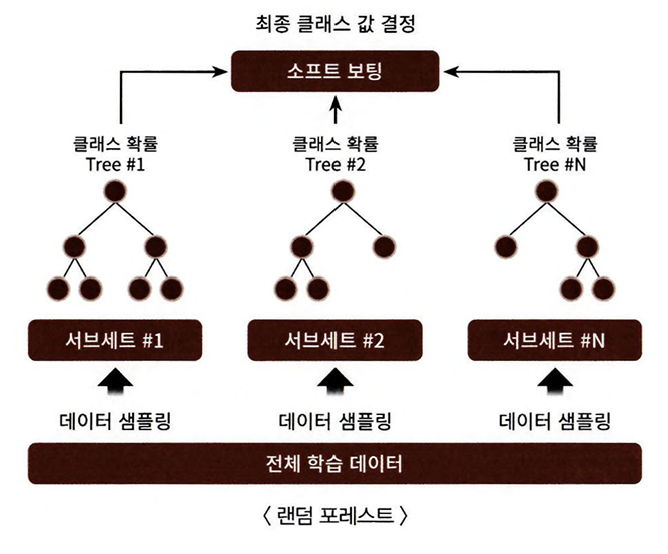

랜덤 포레스트는 개별적인 분류기의 기반 알고리즘은 결정 트리이지만 개별 트리가 학습하는 데이터 세트는 전체 데이터에서 일부가 중첩되게 샘플링된 데이터 세트이다. 이렇게 여러 개의 데이터 세트를 중첩되게 분리하는 것을 부트스트래핑(bootstrapping) 분할 방식이라고 한다(그래서 배깅
(Bagging)이 bootstrap aggregating의 줄임말이다).

원래 부트스트랩은 통계학에서 여러 개의 작은 데이터 세트를 임의로 만들어 개별 평균의 분포도를 측정하는 등의 목적을 위한 샘플링 방식을 지칭
한다. 랜덤 포레스트의 서브세트(Subset) 데이터는 이러한 부트스트래핑으로 데이터가 임의로 만들어진다. 서브세트의 데이터 건수는 전체 데이터 건수와 동일하지만, 개별 데이터가 중첩되어 만들어진다.

사이킷런은 RandomForestClassifier 클래스를 통해 랜덤 포레스트 기반의 분류를 지원한다.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# 코드 추가
def get_new_feature_name_df(old_feature_name_df):
  feature_dup_df=pd.DataFrame(data=old_feature_name_df.groupby('column_name').cumcount(), columns=['dup_cnt'])
  feature_dup_df=feature_dup_df.reset_index()
  new_feature_name_df=pd.merge(old_feature_name_df.reset_index(), feature_dup_df, how='outer')
  new_feature_name_df['column_name']=new_feature_name_df[['column_name','dup_cnt']].apply(lambda x: x[0]+'_'+str(x[1]) if x[1]>0 else x[0], axis=1)
  new_feature_name_df=new_feature_name_df.drop(['index'], axis=1)
  return new_feature_name_df

def get_human_dataset():
  feature_name_df = pd.read_csv('./features.txt', sep='\s+',
                                header=None, names=['column_index', 'column_name'])
  new_feature_name_df = get_new_feature_name_df(feature_name_df)
  feature_name = new_feature_name_df.iloc[:, 1].values.tolist()
  X_train = pd.read_csv('./X_train.txt', sep='\s+', names=feature_name)
  X_test = pd.read_csv('./X_test.txt', sep='\s+', names=feature_name)
  y_train = pd.read_csv('./y_train.txt', sep='\s+', header=None, names=['action'])
  y_test = pd.read_csv('./y_test.txt', sep='\s+', header=None, names=['action'])
  return X_train, X_test, y_train, y_test

# 결정 트리에서 사용한 get_human_dataset()를 이용해 학습/테스트용 DataFrame 반환
X_train, X_test, y_train, y_test = get_human_dataset()

# 랜덤 포레스트 학습 및 별도의 테스트 세트로 예측 성능 평가
rf_clf = RandomForestClassifier(random_state=0, max_depth=8)
rf_clf.fit(X_train, y_train)
pred = rf_clf.predict(X_test)
accuracy = accuracy_score(y_test, pred)
print('랜덤 포레스트 정확도: {0:.4f}'.format(accuracy))

랜덤 포레스트 정확도: 0.9220


#### 랜덤 포레스트 하이퍼 파라미터 및 튜닝

- 트리 기반의 앙상블 알고리즘의 단점

하이퍼 파라미터가 너무 많음

-> 그로 인한 튜닝 시간이 많이 소모됨

튜닝 후 예측 성능이 크게 향상되는 경우가 많지 않음

랜덤 포레스트 하이퍼 파라미터
- n_estimators

: 랜덤 포레스트에서 결정 트리의 개수를 지정. 디폴트는 10개. 많이 설정할수록 좋은 성능을 기대할 수 있지만 계속 증가시킨다고 성능이 무조건 향상되는 것은 아님. 늘릴수록 수행 시간이 오래걸림.
- max_features

: 'None'이 아니라 'auto', 즉 'sqrt'와 같음. 랜덤 포레스트의 트리를 분할하는 피처를 참조할 때 전체 피처가 아니라 sqrt(전체 피처 개수)만큼 참조함. 전체 피처가 16개라면 분할을 위해 4개 참조.
- max_depth, min_samples_leat, min_samples_split: 결정트리에서 과적합을 개선하기 위해 사용됨.

GridSearchCV를 이용해 랜덤 포레스트의 하이퍼 파라미터 튜닝하기

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [8, 16, 24],
    'min_samples_leaf': [1, 6, 12],
    'min_samples_split': [2, 8, 16]
}

# RandomForestClassifier 객체 생성 후 GridSearchCV 수행
rf_clf = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)
grid_cv = GridSearchCV(rf_clf, param_grid=params, cv=2, n_jobs=-1)
grid_cv.fit(X_train, y_train)

print('최적 하이퍼 파라미터:\n', grid_cv.best_params_)
print('최고 예측 정확도: {0:.4f}'.format(grid_cv.best_score_))

최적 하이퍼 파라미터:
 {'max_depth': 16, 'min_samples_leaf': 6, 'min_samples_split': 16}
최고 예측 정확도: 0.9157


다시 RandomForestClassifier를 학습시킨 뒤에, 별도의 테스트 데이터 세트에서 예측 성능 측정

In [ ]:
rf_clf1 = RandomForestClassifier(n_estimators=100, min_samples_leaf=6, max_depth=16,
                                 min_samples_split=2, random_state=0)
rf_clf1.fit(X_train, y_train)
pred = rf_clf1.predict(X_test)
print('예측 정확도: {0:.4f}'.format(accuracy_score(y_test, pred)))

예측 정확도: 0.9253


RandomForestClassifier도 feature_importances_ 속성을 이용해 알고리즘이 선택한 피처의 중요도를 막대그래프로 시각화하기

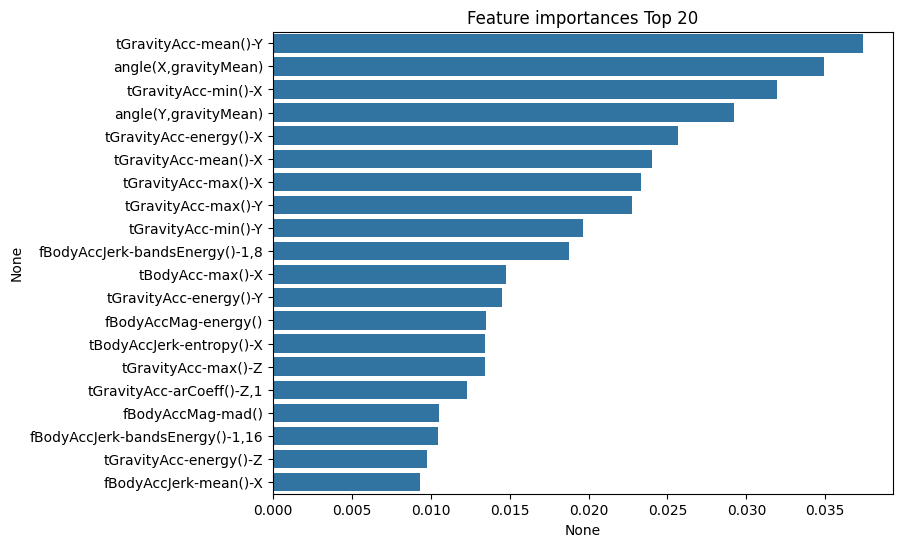

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

ftr_importances_values = rf_clf1.feature_importances_
ftr_importances = pd.Series(ftr_importances_values, index=X_train.columns)
ftr_top20 = ftr_importances.sort_values(ascending=False)[:20]

plt.figure(figsize=(8,6))
plt.title('Feature importances Top 20')
sns.barplot(x=ftr_top20, y=ftr_top20.index)
plt.show()

**GBM(Gradient Boosting Machine)**

#### GBM의 개요 및 실습

부스팅 알고리즘은 여러 개의 약한 학습기(weak learner)를 순차적으로 학습-예측하면서 잘못 예측한 데이터에 가중치 부여를 통해 오류를 개선해 나가면서 학습하는 방식

부스팅의 대표적인 구현 : AdaBoost(Adaptive boosting)

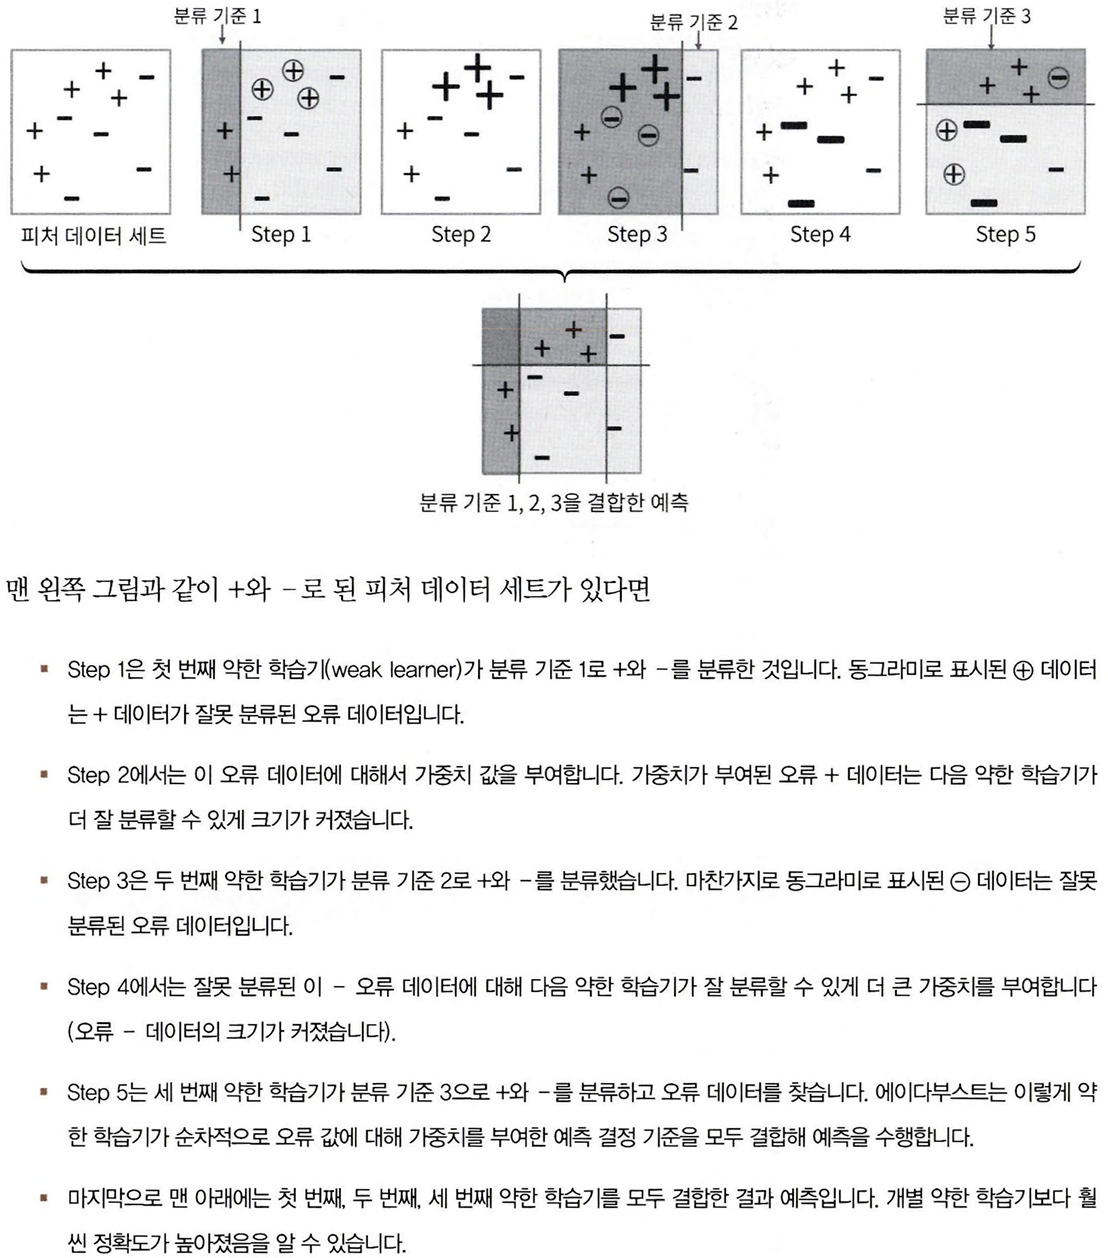

GBM(Gradient Boost Machine)도 에이다부스트와 유사하나, 가중치 업데이트를 경사 하강법(Gradient Descent)을 이용하는 것이 큰 차이.

오류 값은 실제 값 - 예측값이다. 분류의 실제 결괏값을y, 피처를 x_1, x_2, ... , x_n 그리고 이 피처에 기반한 예측 함수를F(x) 함수라고 하면 오류식 h(x) = y - F(x) 이 된다. 이 오류식 h(x) = y - F(x) 를 최소화하는 방향성을 가지고 반복적으로 가중치 값을 업데이트하는 것이 경사 하강법(Gradient Descent)이다.

사이킷런의 GBM을 이용해 사용자 행동 데이터 세트를 예측 분류

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
import time
import warnings
warnings.filterwarnings('ignore')

X_train, X_test, y_train, y_test = get_human_dataset()

# GBM 수행 시간 측정을 위함. 시작 시간 설정.
start_time = time.time()

gb_clf = GradientBoostingClassifier(random_state=0)
gb_clf.fit(X_train, y_train)
gb_pred = gb_clf.predict(X_test)
gb_accuracy = accuracy_score(y_test, gb_pred)

print('GBM 정확도: {0:.4f}'.format(gb_accuracy))
print('GBM 수행 시간: {0:.1f}초'.format(time.time() - start_time))

GBM 정확도: 0.9379
GBM 수행 시간: 1368.2초


- 앞의 랜덤 포레스트보다 나은 예측 성능을 나타냄 (항상 그런 것은 아니지만 일반적으로..)
- 수행 시간이 오래 걸리고 하이퍼 파라미터 튜닝 노력이 더 필요함

#### GBM 하이퍼 파라미터 소개

- loss : 경사 하강법에서 사용할 비용 함수를 지정. 특별한 이유가 없으면 기본값인 'deviance'를 그대로 적용
- learning_rate : GBM이 학습을 진행할 때마다 적용하는 학습률. Weak learner가 순차적으로 오류 값을 보정해 나가는 데 적용하는 계수. 0~1 사이의 값을 지정할 수 있으며 기본값은 0.1. 너무 작은 값을 적용하면 업데이트되는 값이 작아져서 최소 오류 값을 찾아 예측 성능이 높아질 가능성이 높음. 너무 크면 예측 성능이 떨어질 가능성은 높지만 빠른 수행 가능. n_estimators와 상호 보완적으로 조합해 사용. learning_rate를 작게 하고 n_estimators를 크게 하면 더 이상 성능이 좋아지지 않는 한계점까지는 예측 성능이 조금씩 좋아짐.
- n_estimators : weak learner의 개수. weak learner가 순차적으로 오류를 보정하므로 개수가 많을수록 예측 성능이 일정 수준까지는 좋아짐. 개수가 많을수록 수행 시간이 오래 걸림. 기본값: 100
- subsample : weak learner가 학습에 사용하는 데이터의 샘플링 비율. 기본값: 1. 전체 학습 데이터를 기반으로 학습한다는 의미(0.5이면 학습 데이터의 50%). 과적합이 염려되는 경우 subsample을 1보다 작은 값으로 설정

** XGBoost(eXtra Gradient Boost)**

#### XGBoost 개요

- 뛰어난 예측 성능 : 분류와 회귀 영역에서
- GBM 대비 빠른 수행 시간 : 그렇지만 다른 머신러닝 알고리즘보다는 느림
- 과적합 규제(Regularization) : 과적합에 좀 더 강한 내구성을 가짐
- Tree pruning(나무 가지치기) : 더 이상 긍정 이득이 없는 분할을 가지치기 해서 분할 수를 더 줄임
- 자체 내장된 교차 검증 : 반복 수행 시마다 내부적으로 학습 데이터 세트와 평가 데이터 세트에 대한 교차 검증을 수행해 최적화된 반복 수행 횟수를 가질 수 있음
- 결손값 자체 처리

XGBoost 설치하기

In [ ]:
# pip install xgboost==1.5.0

In [ ]:
import xgboost as xgb
from xgboost import XGBClassifier

#### 파이썬 래퍼 XGBoost 하이퍼 파라미터

- GBM과 유사한 하이퍼 파라미터를 동일하게 가지고 있음
- 조기 중단, 과적합을 규제하기 위한 하이퍼 파라미터가 추가됨

파이썬 래퍼 XGBoost 하이퍼 파라미터를 유형별로 나누면
- 일반 파라미터: 일반적으로 실행 시 스레드의 개수나 silent 모드 등의 선택을 위한 파라미터 디폴트 파라미터 값을 바꾸는 경우는 거의 없음
- 부스터 파라미터: 트리 최적화, 부스팅, regularization 등과 관련 파라미터 등을 지칭함/대부분의 파라미터는 여기 속함
- 학습 테스크 파라미터: 학습 수행 시의 객체 함수, 평가를 위한 지표 등을 설명하는 파라미터

주요 일반 파라미터
- booster: gbtree(tree based model) 또는 gblinear(linear model) 선택. 디폴트는 gbtree
- silent: 디폴트는 0이며, 출력 메시지를 나타내고 싶지 않을 경우 1로 설정
- nthread: CPU의 실행 스레드 개수를 조정하며, 디폴트는 CPU의 전체 스레드를 다 사용하는 것이다. 멀티 코어/스레드 CPU 시스템에서 전체 CPU를 사용하지 않고 일부 CPU만 사용해 ML 애플리케이션을 구동하는 경우에 변경한다.

주요 부스터 파라미터
- eta [default=0.3, alias: learning_rate]: GBM의 학습률(learning rate)과 같은 파라미터. 0에서 1 사이의 값을 지정하며 부스팅 스텝을 반복적으로 수행할 때 업데이트되는 학습률 값. 파이썬 래퍼 기반의 xgboost를 이용할 경우 디폴트는 0.3. 사이킷런 래퍼 클래스를 이용할 경우 eta는 learning_rate 파라미터로 대체되며, 디폴트는 0.1. 보통은 0.01 ~ 0.2 사이의 값을 선호한다.
- num_boost_rounds: GBM의 n_estimators와 같은 파라미터.
- min_child_weight [default=1]: 트리에서 추가적으로 가지를 나눌지를 결정하기 위해 필요한 데이터들의 weight 총합. min_child_weight이 클수록 분할을 자제한다. 과적합을 조절하기 위해 사용된다.
- gamma [default=0, alias: min_split_loss]: 트리의 리프 노드를 추가적으로 나눌지를 결정할 최소 손실 감소 값. 해당 값보다 큰 손실(loss)이 감소된 경우에 리프 노드를 분리한다. 값이 클수록 과적합 감소 효과가 있다.
- max_depth [default=6]: 트리 기반 알고리즘의 max_depth와 같다. 0을 지정하면 깊이에 제한이 없다. Max_depth가 높으면 특정 피처 조건에 특화되어 룰 조건이 만들어지므로 과적합 가능성이 높아지며 보통은 3~10 사이의 값을 적용한다.
- sub_sample [default=1]: GBM의 subsample과 동일. 트리가 커져서 과적합되는 것을 제어하기 위해 데이터를 샘플링하는 비율을 지정한다. sub_sample=0.5로 지정하면 전체 데이터의 절반을 트리를 생성하는 데 사용. 0에서 1 사이의 값이 가능하나 일반적으로 0.5 ~ 1 사이의 값을 사용.
- colsample_bytree [default=1]: GBM의 max_features와 유사. 트리 생성에 필요한 피처(칼럼)를 임의로 샘플링하는 데 사용된다. 매우 많은 피처가 있는 경우 과적합을 조정하는 데 적용한다.
- lambda [default=1, alias: reg_lambda]: L2 Regularization 적용 값. 피처 개수가 많을 경우 적용을 검토하며 값이 클수록 과적합 감소 효과가 있다.
- alpha [default=0, alias: reg_alpha]: L1 Regularization 적용 값. 피처 개수가 많을 경우 적용을 검토하며 값이 클수록 과적합 감소 효과가 있다.
- scale_pos_weight [default=1]: 특정 값으로 치우친 비대칭한 클래스로 구성된 데이터 세트의 균형을 유지하기 위한 파라미터.

학습 테스크 파라미터
- objective: 최솟값을 가져야 할 손실 함수를 정의한다. XGBoost는 많은 유형의 손실함수를 사용할 수 있다. 주로 사용되는 손실함수는 이진 분류인지 다중 분류인지에 따라 달라진다.
- binary:logistic: 이진 분류일 때 적용한다.
- multi:softmax: 다중 분류일 때 적용한다. 손실함수가 multi:softmax일 경우에는 레이블 클래스의 개수인 num_class 파라미터를 지정해야 한다.
- multi:softprob: multi:softmax와 유사하나 개별 레이블 클래스의 해당되는 예측 확률을 반환한다.
- eval_metric: 검증에 사용되는 함수를 정의한다. 기본값은 회귀인 경우는 rmse, 분류일 경우에는 error이다. 다음은 eval_metric의 값 유형이다.

rmse: Root Mean Square Error

mae: Mean Absolute Error

logloss: Negative log-likelihood

error: Binary classification error rate (0.5 threshold)

merror: Multiclass classification error rate

mlogloss: Multiclass logloss

auc: Area under the curve

과적합 문제가 심각하면 고려할 수 있는 것
- eta 값 ↓ (0.01~0.1). num_round(또는 n_estimators) ↑
- max_depth 값 ↓
- min_child_weight ↑
- gamma ↑
- subsample과 colsample_bytree 조정

성능 향상 기능
- 조기 중단(Early Stopping)

n_estimators에 지정된 횟수만큼 반복적으로 학습 오류를 감소시키며 학습을 진행하면서 중간에 반복을 멈출 수 없고 n_estimators에 지정된 횟수를 다 완료해야 함.

조기 중단하면 횟수 도달하지 않더라도 예측 오류가 개선되지 않으면 중간에 중지해 수행 시간 개선 가능.

In [ ]:
import xgboost
print(xgboost.__version__)

3.2.0


#### 파이썬 래퍼 XGBoost 적용 - 위스콘신 유방암 예측
- 악성 종양(malignant): 빠르게 성장. 신체 각 부위에 확산/전이되어 생명 위협
- 양성 종양(benign): 성장 속도가 느리고 전이되지 않음.

In [ ]:
import xgboost as xgb
from xgboost import plot_importance
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

dataset = load_breast_cancer()
features = dataset.data
labels = dataset.target

cancer_df = pd.DataFrame(data=features, columns = dataset.feature_names)
cancer_df['target']=labels
cancer_df.head(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0


In [ ]:
print(dataset.target_names)
print(cancer_df['target'].value_counts())

['malignant' 'benign']
target
1    357
0    212
Name: count, dtype: int64


1값인 양성 benign이 357개, 0값인 악성 malignant가 212개로 구성됨

In [ ]:
# cancer_df에서 feature용 DataFrame과 Label용 Series 객체 추출
# 맨 마지막 칼럼이 Label임. Feature용 DataFrame은 cancer_df의 첫번째 칼럼에서 맨 마지막 두번째 칼럼까지를 :-1슬라이싱으로 추출.
X_features = cancer_df.iloc[:,:-1]
y_label = cancer_df.iloc[:,-1]

# 전체 데이터 중 80%는 학습용 데이터, 20%는 테스트용 데이터 추출
X_train, X_test, y_train, y_test = train_test_split(X_features, y_label, test_size=0.2, random_state=156)

# 위에서 만든 X_train, y_train을 다시 쪼개서 90%는 학습과 10%는 검증용 데이터로 분리
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=156)

print(X_train.shape, X_test.shape)
print(X_tr.shape, X_val.shape)

(455, 30) (114, 30)
(409, 30) (46, 30)


전체 569개의 데이터 세트에서 최종 학습용 409개, 검증용 46개, 테스트용 114개가 추출됨

- DMatrix : XGBoost 만의 전용 데이터 객체

넘파이, DataFrame, Series외에 libsvm txt 포맷 파일, xgboost 이진 버퍼 파일을 파라미터로 입력받아 변환할 수 있다. 과거 버전의 XGBoost에서 판다스의 DataFrame과 호환되지 않아서 DMatrix 생성 시 오류가 발생할 경우에는 DataFrame.values를 이용해 넘파이로 일차 변환한
뒤에 이를 이용해 DMatrix 변환을 적용해야 한다.

In [ ]:
# 만약 구버전 XGBoost에서 DataFrame으로 DMatrix 생성이 안 될 경우 X_train.values로 넘파이 변환.
# 학습, 검증, 테스트용 DMatirx를 생성.
dtr = xgb.DMatrix(data=X_tr, label=y_tr)
dval = xgb.DMatrix(data=X_val, label=y_val)
dtest = xgb.DMatrix(data=X_test, label=y_test)

In [ ]:
params = {'max_depth':3, #트리 최대 깊이
          'eta': 0.05, #학습률
          'objective': 'binary:logistic', #예제 데이터가 0 또는 1 이진분류 이므로
          'eval_metric':'logloss' #오류함수의 평가 성능 지표
}
num_rounds = 400 #부스팅 반복 횟수

- 평가용 데이터 세트는 학습과 평가용 데이터 세트를 명기하는 개별 튜플을 가지는 리스트 형태로 설정. 가령 dtrO| 학습용, dval이 평가용이라면 [(dtr,'train1'),(dval,'eval')]와 같이, 학습용 DMatirx는 ‘train’으로, 평가용 Dmatrix는 ‘eval’로 개별 튜플에서 명기하여 설정. 과거 버전 XGBoost는 학습 데이터 세트와 평가용 데이터 세트를 명기해주어야 했으나 현재 버전은 평가용 데이터 세트만 명기해 줘도 성능 평가를 수행하므로 [(dval, 'eval')]로 설정해도 무방
- eval_metric은 평가 세트에 적용할 성능 평가 방법. 분류일 경우 주로 ‘error’(분류 오류), ‘logloss’를 적용

xgboost 모듈의 train() 함수를 호출해 학습을 수행

In [ ]:
# 학습 데이터 셋은 'train' 또는 평가 데이터 셋은 'eval'로 명기합니다.
eval_list = [(dtr,'train'),(dval,'eval')] # 또는 eval_list = [(dval,'eval')]만 명기해도 무방.

# 하이퍼 파라미터와 early stopping 파라미터를 train() 함수의 파라미터로 전달
xgb_model = xgb.train(params = params, dtrain=dtr, num_boost_round=num_rounds,
                      early_stopping_rounds=50, evals=eval_list)

[0]	train-logloss:0.62473	eval-logloss:0.63088
[1]	train-logloss:0.58662	eval-logloss:0.60461
[2]	train-logloss:0.55210	eval-logloss:0.58205
[3]	train-logloss:0.52068	eval-logloss:0.56165
[4]	train-logloss:0.49173	eval-logloss:0.54101
[5]	train-logloss:0.46517	eval-logloss:0.52206
[6]	train-logloss:0.44009	eval-logloss:0.50271
[7]	train-logloss:0.41646	eval-logloss:0.48606
[8]	train-logloss:0.39505	eval-logloss:0.46961
[9]	train-logloss:0.37523	eval-logloss:0.45485
[10]	train-logloss:0.35682	eval-logloss:0.44120
[11]	train-logloss:0.33964	eval-logloss:0.43123
[12]	train-logloss:0.32279	eval-logloss:0.41962
[13]	train-logloss:0.30783	eval-logloss:0.40848
[14]	train-logloss:0.29308	eval-logloss:0.39857
[15]	train-logloss:0.27928	eval-logloss:0.38945
[16]	train-logloss:0.26681	eval-logloss:0.38171
[17]	train-logloss:0.25498	eval-logloss:0.37381
[18]	train-logloss:0.24352	eval-logloss:0.36656
[19]	train-logloss:0.23307	eval-logloss:0.36014
[20]	train-logloss:0.22290	eval-logloss:0.35395
[2

- 반복 시마다 train-logloss와 eval-logloss가 지속적으로 감소
- 학습을 176번째 반복에서 완료함

126번째 반복에서 eval-logloss로 표시되는 검증 데이터에 대한 lo읺oss 값이 0.25587로 가장 낮다. 이후 126번에서 176번까지 early_stopping_rounds로 지정된 50회 동안 logloss 값은 이보다 향상되지 않았기 때문에(logloss가 작을수록 성능이 좋습니다) 더 이상 반복하지 않고 멈춘 것이다.

xgboost를 이용해 테스트 데이터 세트에 예측을 수행

In [ ]:
pred_probs = xgb_model.predict(dtest)
print('predict() 수행 결과값을 10개만 표시, 예측 확률 값으로 표시됨')
print(np.round(pred_probs[:10],3))

# 예측 확률이 0.5보다 크면 1, 그렇지 않으면 0으로 예측값 결정하여 List 객체인 preds에 저장
preds = [1 if x>0.5 else 0 for x in pred_probs]
print('예측값 10개만 표시:', preds[:10])

predict() 수행 결과값을 10개만 표시, 예측 확률 값으로 표시됨
[0.938 0.004 0.776 0.058 0.975 1.    0.999 0.999 0.998 0.   ]
예측값 10개만 표시: [1, 0, 1, 0, 1, 1, 1, 1, 1, 0]


In [ ]:
def get_clf_eval(y_test, pred, pred_proba):
  confusion=confusion_matrix(y_test,pred)
  accuracy=accuracy_score(y_test, pred)
  precision=precision_score(y_test, pred)
  recall=recall_score(y_test,pred)
  f1=f1_score(y_test, pred)
  roc_auc=roc_auc_score(y_test,pred)
  print('오차행렬')
  print(confusion)
  print('정확도:{0:.4f},정밀도:{1:.4f},재현율:{2:.4f},F1:{3:.4f}, AUC:{4:.4f}'.format(accuracy,precision,recall,f1,roc_auc))

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

get_clf_eval(y_test, preds, pred_probs)

오차행렬
[[35  2]
 [ 2 75]]
정확도:0.9649,정밀도:0.9740,재현율:0.9740,F1:0.9740, AUC:0.9600


xgboost 패키지에 내장된 시각화 기능 수행

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

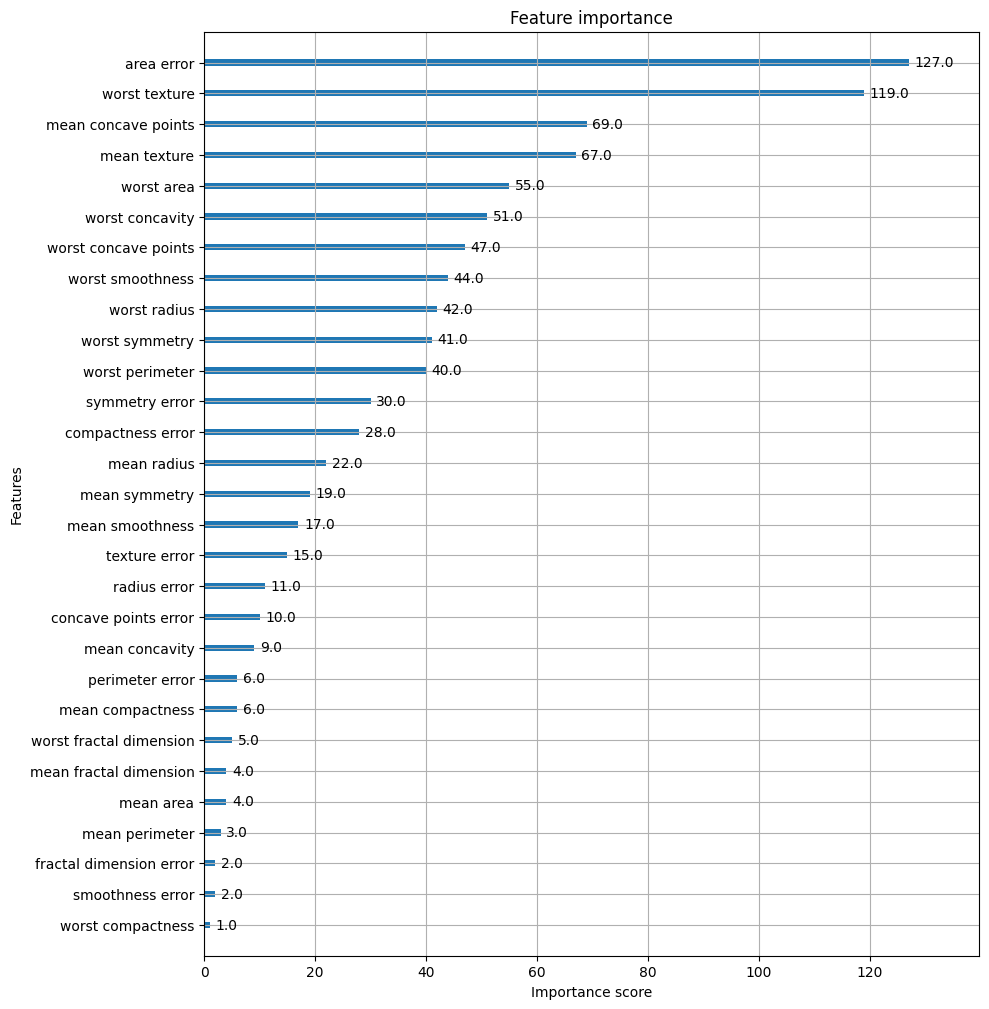

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(10,12))
plot_importance(xgb_model, ax=ax)

xgboost 모듈의 to_graphviz( ) API를 이용하면 주피터 노트북에 바로 규칙 트리 구조를 그릴 수 있다. 단, 결정 트리에서와 마찬가지로 Graphviz 프로그램과 패키지가 설치돼 있어야 한다. xgboost.to_ graphviz() 내에 파라미터로 학습이 완료된 모델 객체와 Graphviz가 참조할 파일명을 입력하면 된다.

cv() API와 파라미터에 대한 설명

xgboost.cv(params, dtrain, num_boost_ro나nd=10, nfold=3, stratified=False, folds=Nonez metrics=(), obj=None, feval=None, maximize=False, early_stopping_rounds=Non은, fpreproc=None, as_pandas=True, verbose_eval=None, show_stdv=True, seed=Gz callbacks=None, shuffle=True)
- params (dict) : 부스터 파라미터
- dtrain (DMatrix) : 학습 데이터
- num_boost_round (int) : 부스팅 반복 횟수
- nflod (int) : CV 폴드 개수
- stratified (bool) : CV 수행 시 층화 표본 추출 수행 여부
- metric (string or list of strings) : CV 수행 시 모니터링할 성능 평가 지표
- early_stopping_rounds (int) : 조기 중단을 활성화시킴. 반복횟수 지정

vgb.cv의 반환값 : DataFrame 형태

#### 사이킷런 래퍼 XGBoost의 개요 및 적용
- eta -> learning_rate
- sub_sample -> subsample
- lambda -> reg_lambda
- alpha -> reg_alpha

In [ ]:
# 사이킷런 래퍼 XGBoost 클래스인 XGBClassifier 임포트
from xgboost import XGBClassifier

# Warning 메시지를 없애기 위해 eval_metric 값을 XGBClassifier 생성 인자로 입력.
xgb_wrapper = XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=3, eval_metric='logloss')
xgb_wrapper.fit(X_train, y_train, verbose=True)
w_preds = xgb_wrapper.predict(X_test)
w_pred_proba = xgb_wrapper.predict_proba(X_test)[:,1]

In [ ]:
get_clf_eval(y_test, w_preds, w_pred_proba)

오차행렬
[[34  3]
 [ 1 76]]
정확도:0.9649,정밀도:0.9620,재현율:0.9870,F1:0.9744, AUC:0.9530


조기 중단 수행 -> 조기 중단 관련 파라미터를 fit()에 입력

In [ ]:
from xgboost import XGBClassifier

xgb_wrapper = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=3,
    early_stopping_rounds=50,
    eval_metric='logloss'
)

evals = [(X_tr, y_tr), (X_val, y_val)]

xgb_wrapper.fit(X_tr, y_tr, eval_set=evals, verbose=True)

ws50_preds = xgb_wrapper.predict(X_test)
ws50_pred_proba = xgb_wrapper.predict_proba(X_test)[:, 1]

[0]	validation_0-logloss:0.62473	validation_1-logloss:0.63088
[1]	validation_0-logloss:0.58662	validation_1-logloss:0.60461
[2]	validation_0-logloss:0.55210	validation_1-logloss:0.58205
[3]	validation_0-logloss:0.52068	validation_1-logloss:0.56165
[4]	validation_0-logloss:0.49173	validation_1-logloss:0.54101
[5]	validation_0-logloss:0.46517	validation_1-logloss:0.52206
[6]	validation_0-logloss:0.44009	validation_1-logloss:0.50271
[7]	validation_0-logloss:0.41646	validation_1-logloss:0.48606
[8]	validation_0-logloss:0.39505	validation_1-logloss:0.46961
[9]	validation_0-logloss:0.37523	validation_1-logloss:0.45485
[10]	validation_0-logloss:0.35682	validation_1-logloss:0.44120
[11]	validation_0-logloss:0.33964	validation_1-logloss:0.43123
[12]	validation_0-logloss:0.32279	validation_1-logloss:0.41962
[13]	validation_0-logloss:0.30783	validation_1-logloss:0.40848
[14]	validation_0-logloss:0.29308	validation_1-logloss:0.39857
[15]	validation_0-logloss:0.27928	validation_1-logloss:0.38945
[1

In [ ]:
get_clf_eval(y_test, ws50_preds, ws50_pred_proba)

오차행렬
[[35  2]
 [ 2 75]]
정확도:0.9649,정밀도:0.9740,재현율:0.9740,F1:0.9740, AUC:0.9600


But 조기 중단값을 너무 급격하게 줄이면 예측 성능이 저하될 우려가 크다.

In [ ]:
# early_stopping_rounds를 10으로 설정하고 재학습.
xgb_wrapper=XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=3,
                          early_stopping_rounds=10, eval_metric='logloss')
xgb_wrapper.fit(X_tr,y_tr, eval_set=evals, verbose=True)
ws10_preds=xgb_wrapper.predict(X_test)
ws10_preds_proba=xgb_wrapper.predict_proba(X_test)[:,1]
get_clf_eval(y_test, ws10_preds, ws10_preds_proba)

[0]	validation_0-logloss:0.62473	validation_1-logloss:0.63088
[1]	validation_0-logloss:0.58662	validation_1-logloss:0.60461
[2]	validation_0-logloss:0.55210	validation_1-logloss:0.58205
[3]	validation_0-logloss:0.52068	validation_1-logloss:0.56165
[4]	validation_0-logloss:0.49173	validation_1-logloss:0.54101
[5]	validation_0-logloss:0.46517	validation_1-logloss:0.52206
[6]	validation_0-logloss:0.44009	validation_1-logloss:0.50271
[7]	validation_0-logloss:0.41646	validation_1-logloss:0.48606
[8]	validation_0-logloss:0.39505	validation_1-logloss:0.46961
[9]	validation_0-logloss:0.37523	validation_1-logloss:0.45485
[10]	validation_0-logloss:0.35682	validation_1-logloss:0.44120
[11]	validation_0-logloss:0.33964	validation_1-logloss:0.43123
[12]	validation_0-logloss:0.32279	validation_1-logloss:0.41962
[13]	validation_0-logloss:0.30783	validation_1-logloss:0.40848
[14]	validation_0-logloss:0.29308	validation_1-logloss:0.39857
[15]	validation_0-logloss:0.27928	validation_1-logloss:0.38945
[1

피처의 중요도를 시각화하는 모듈인 plot_importance() API에 사이킷런 래퍼 클래스를 입력해도 앞과 같은 시각화 결과를 도출함

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

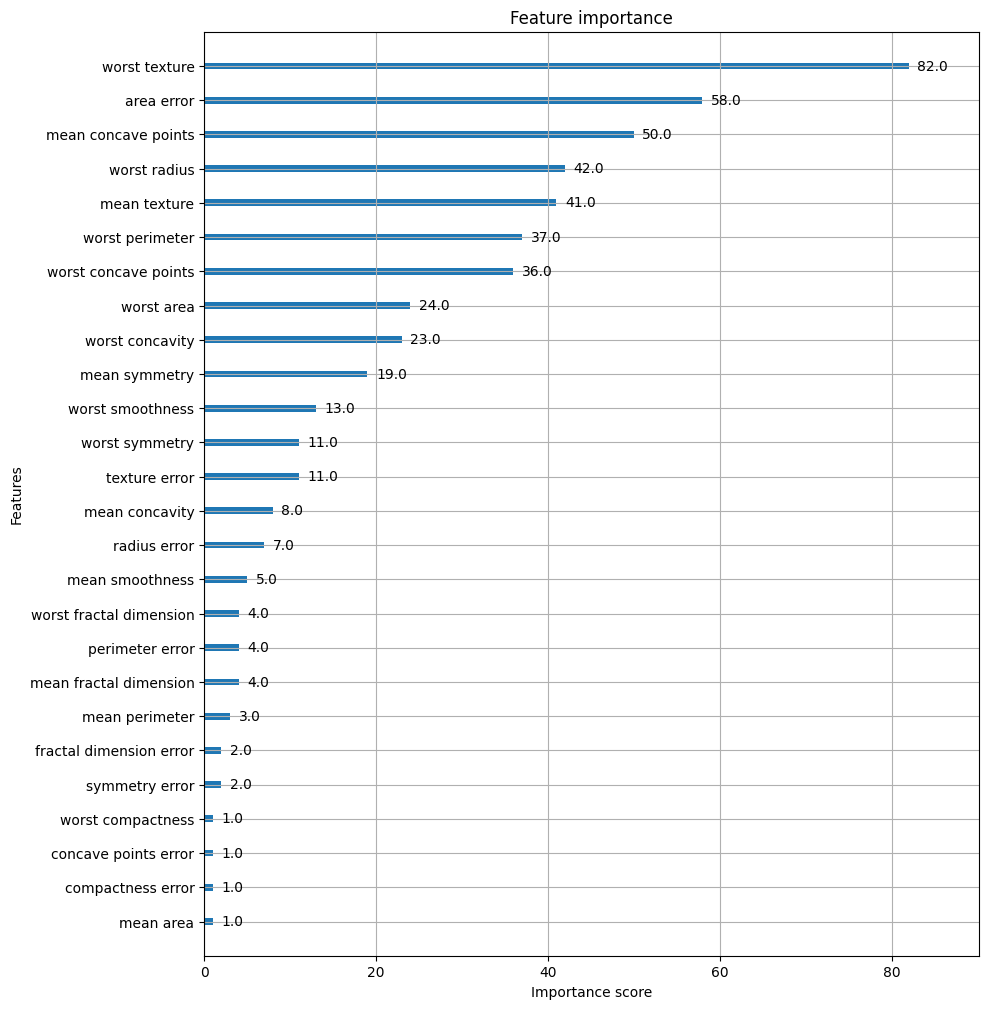

In [ ]:
from xgboost import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(10,12))
# 사이킷런 래퍼 클래스를 입력해도 무방.
plot_importance(xgb_wrapper, ax=ax)